# 🧠 Redes Neuronales desde Cero
### Práctica Guiada: Perceptrón → Red de Una Capa → Red Multicapa

---

**Objetivo:** Implementar y validar redes neuronales básicas comprendiendo sus fundamentos:
entradas, pesos, sesgo (bias), puntaje z, función de activación y clasificación binaria.

**Estructura del cuaderno:**
1. Perceptrón simple (clasificación linealmente separable)
2. Red neuronal de una capa (con entrenamiento)
3. Red neuronal multicapa (MLP con backpropagation)
4. Conclusiones técnicas

## ⚙️ Importación de Librerías

In [1]:
# Librerías estándar para cómputo numérico y visualización
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Semilla aleatoria para reproducibilidad
np.random.seed(42)

print("✅ Librerías importadas correctamente.")

✅ Librerías importadas correctamente.


---
## PARTE 1: Perceptrón Simple

### ¿Qué es un perceptrón?
El **perceptrón** es la unidad más básica de una red neuronal. Funciona así:

1. Recibe **entradas** (`x₁, x₂, ...`)
2. Multiplica cada entrada por un **peso** (`w₁, w₂, ...`)
3. Suma los productos más un **sesgo (bias)** → obtiene el **puntaje z**
4. Aplica una **función de activación** (umbral): si z ≥ 0 → salida = 1, si z < 0 → salida = 0

**Fórmula:** `z = w₁·x₁ + w₂·x₂ + ... + b`

Solo puede resolver problemas **linealmente separables** (AND, OR, etc.)

In [2]:
class Perceptron:
    """
    Perceptrón simple con aprendizaje por regla de actualización de Rosenblatt.

    Parámetros:
        tasa_aprendizaje (float): Cuánto ajustamos los pesos en cada error.
        epocas (int): Número de pasadas completas sobre los datos de entrenamiento.
    """

    def __init__(self, tasa_aprendizaje=0.1, epocas=10):
        self.tasa_aprendizaje = tasa_aprendizaje
        self.epocas = epocas
        self.pesos = None   # Se inicializan al entrenar
        self.bias = None
        self.historial_errores = []  # Para graficar la convergencia

    # ── Función de activación ──────────────────────────────────────────────────
    def _activacion_umbral(self, z):
        """
        Función escalón: devuelve 1 si z >= 0, de lo contrario 0.
        Es la regla de decisión del perceptrón.
        """
        return 1 if z >= 0 else 0

    # ── Predicción para una muestra ───────────────────────────────────────────
    def _predecir_uno(self, x):
        """
        Calcula el puntaje z y aplica la activación para una muestra.
        z = w · x + b
        """
        z = np.dot(self.pesos, x) + self.bias  # Puntaje z
        return self._activacion_umbral(z)

    # ── Entrenamiento ─────────────────────────────────────────────────────────
    def entrenar(self, X, y):
        """
        Ajusta pesos y bias usando la regla del perceptrón:
            w ← w + α · (y_real - y_pred) · x
            b ← b + α · (y_real - y_pred)

        Parámetros:
            X (np.ndarray): Matriz de entradas [n_muestras, n_características]
            y (np.ndarray): Etiquetas reales [n_muestras]
        """
        n_caracteristicas = X.shape[1]

        # Inicialización de pesos en cero (o pequeños aleatorios)
        self.pesos = np.zeros(n_caracteristicas)
        self.bias = 0

        for epoca in range(self.epocas):
            errores_epoca = 0

            for x_i, y_real in zip(X, y):
                y_pred = self._predecir_uno(x_i)
                error = y_real - y_pred

                # Actualización de pesos y bias solo si hay error
                self.pesos += self.tasa_aprendizaje * error * x_i
                self.bias  += self.tasa_aprendizaje * error

                errores_epoca += int(error != 0)

            self.historial_errores.append(errores_epoca)
            print(f"  Época {epoca+1:2d} → Errores: {errores_epoca}")

            # Parada temprana: si no hay errores, el modelo convergió
            if errores_epoca == 0:
                print(f"\n✅ Convergencia alcanzada en la época {epoca+1}.")
                break

    # ── Predicción masiva ─────────────────────────────────────────────────────
    def predecir(self, X):
        """Predice la clase (0 o 1) para un conjunto de muestras."""
        return np.array([self._predecir_uno(x) for x in X])

    # ── Exactitud ─────────────────────────────────────────────────────────────
    def exactitud(self, X, y):
        """Calcula el porcentaje de muestras clasificadas correctamente."""
        predicciones = self.predecir(X)
        return np.mean(predicciones == y) * 100


print("✅ Clase Perceptron definida.")

✅ Clase Perceptron definida.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Prueba 1: Compuerta lógica AND (problema linealmente separable)
# ─────────────────────────────────────────────────────────────────────────────

# Tabla de verdad AND
# x1  x2  | AND
#  0   0   |  0
#  0   1   |  0
#  1   0   |  0
#  1   1   |  1
X_and = np.array([[0,0], [0,1], [1,0], [1,1]])
y_and = np.array([0, 0, 0, 1])

print("=" * 45)
print("  PERCEPTRÓN - Compuerta AND")
print("=" * 45)

# Crear y entrenar el perceptrón
p_and = Perceptron(tasa_aprendizaje=0.1, epocas=15)
p_and.entrenar(X_and, y_and)

# Mostrar resultados
print(f"\nPesos aprendidos : {p_and.pesos}")
print(f"Bias aprendido   : {p_and.bias}")
print(f"Exactitud final  : {p_and.exactitud(X_and, y_and):.1f}%")

print("\n--- Predicciones vs Reales ---")
for x, y_real in zip(X_and, y_and):
    z = np.dot(p_and.pesos, x) + p_and.bias
    pred = p_and._predecir_uno(x)
    estado = "✅" if pred == y_real else "❌"
    print(f"  Entrada: {x}  z={z:.2f}  Predicción: {pred}  Real: {y_real}  {estado}")

  PERCEPTRÓN - Compuerta AND
  Época  1 → Errores: 2
  Época  2 → Errores: 3
  Época  3 → Errores: 3
  Época  4 → Errores: 0

✅ Convergencia alcanzada en la época 4.

Pesos aprendidos : [0.2 0.1]
Bias aprendido   : -0.20000000000000004
Exactitud final  : 100.0%

--- Predicciones vs Reales ---
  Entrada: [0 0]  z=-0.20  Predicción: 0  Real: 0  ✅
  Entrada: [0 1]  z=-0.10  Predicción: 0  Real: 0  ✅
  Entrada: [1 0]  z=-0.00  Predicción: 0  Real: 0  ✅
  Entrada: [1 1]  z=0.10  Predicción: 1  Real: 1  ✅


  PERCEPTRÓN - Compuerta OR
  Época  1 → Errores: 2
  Época  2 → Errores: 2
  Época  3 → Errores: 1
  Época  4 → Errores: 0

✅ Convergencia alcanzada en la época 4.

Exactitud final: 100.0%


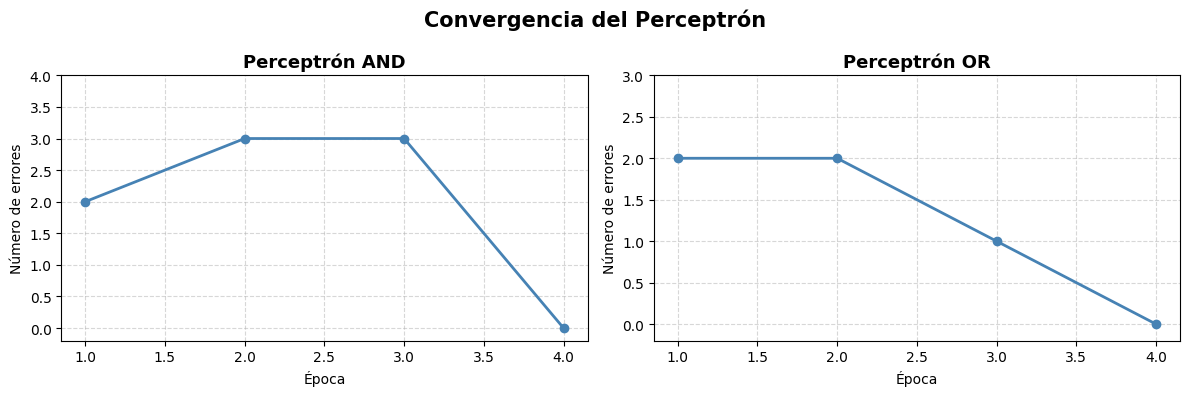


💡 Observación: El perceptrón converge rápidamente en problemas linealmente separables.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Prueba 2: Compuerta lógica OR
# ─────────────────────────────────────────────────────────────────────────────
X_or = np.array([[0,0], [0,1], [1,0], [1,1]])
y_or = np.array([0, 1, 1, 1])

print("=" * 45)
print("  PERCEPTRÓN - Compuerta OR")
print("=" * 45)

p_or = Perceptron(tasa_aprendizaje=0.1, epocas=15)
p_or.entrenar(X_or, y_or)

print(f"\nExactitud final: {p_or.exactitud(X_or, y_or):.1f}%")

# ─────────────────────────────────────────────────────────────────────────────
# Gráfico: Convergencia del error en AND y OR
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, modelo, titulo in zip(
    axes,
    [p_and, p_or],
    ["Perceptrón AND", "Perceptrón OR"]
):
    ax.plot(range(1, len(modelo.historial_errores)+1),
            modelo.historial_errores, marker='o', color='steelblue', linewidth=2)
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_xlabel("Época")
    ax.set_ylabel("Número de errores")
    ax.set_ylim(-0.2, max(modelo.historial_errores) + 1)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Convergencia del Perceptrón", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n💡 Observación: El perceptrón converge rápidamente en problemas linealmente separables.")

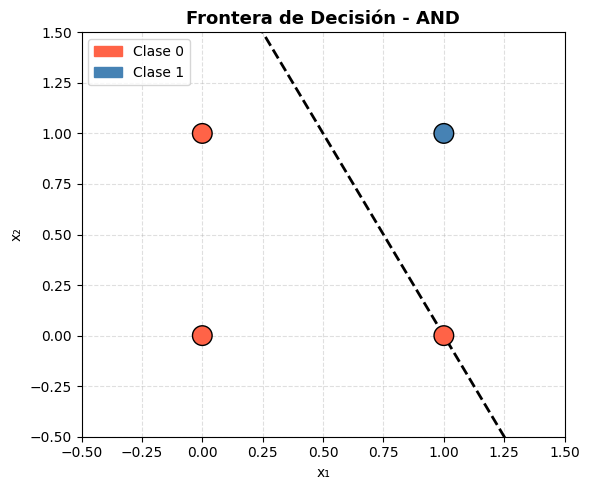

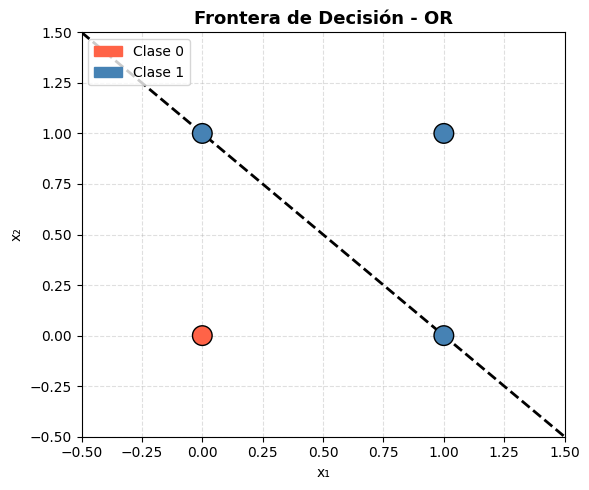

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualización: Frontera de decisión del perceptrón AND
# ─────────────────────────────────────────────────────────────────────────────

def graficar_frontera(modelo, X, y, titulo):
    """
    Dibuja la frontera de decisión lineal aprendida por el perceptrón.
    La línea se obtiene despejando x2 de la ecuación: w1*x1 + w2*x2 + b = 0
    """
    fig, ax = plt.subplots(figsize=(6, 5))

    # Graficar puntos
    colores = ['tomato' if etq == 0 else 'steelblue' for etq in y]
    ax.scatter(X[:, 0], X[:, 1], c=colores, s=200, zorder=3, edgecolors='black')

    # Frontera de decisión: x2 = -(w1*x1 + b) / w2
    if modelo.pesos[1] != 0:
        x1_vals = np.linspace(-0.5, 1.5, 100)
        x2_vals = -(modelo.pesos[0] * x1_vals + modelo.bias) / modelo.pesos[1]
        ax.plot(x1_vals, x2_vals, 'k--', linewidth=2, label='Frontera de decisión')

    # Leyenda
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel("x₁")
    ax.set_ylabel("x₂")
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    parche0 = mpatches.Patch(color='tomato', label='Clase 0')
    parche1 = mpatches.Patch(color='steelblue', label='Clase 1')
    ax.legend(handles=[parche0, parche1], loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

graficar_frontera(p_and, X_and, y_and, "Frontera de Decisión - AND")
graficar_frontera(p_or,  X_or,  y_or,  "Frontera de Decisión - OR")

---
## PARTE 2: Red Neuronal de Una Capa (Single-Layer)

Una **red de una capa** tiene:
- Una **capa de entrada**
- Una **capa de salida** con función de activación sigmoide (salida continua entre 0 y 1)
- Entrenamiento con **descenso de gradiente** y función de costo **entropía cruzada binaria**

Esto equivale a una **regresión logística**, pero implementada desde cero como red neuronal.

> **Diferencia con el perceptrón:** En lugar de ajustar pesos solo cuando hay error,
> aquí minimizamos continuamente una función de costo usando gradientes.

In [6]:
class RedUnaCapа:
    """
    Red neuronal de una sola capa de salida.
    Equivale a regresión logística implementada como red neuronal.

    Arquitectura:
        Entrada (n) → [pesos W, bias b] → Sigmoide → Salida (1)

    Parámetros:
        tasa_aprendizaje (float): Paso del descenso de gradiente.
        epocas (int): Iteraciones de entrenamiento.
    """

    def __init__(self, tasa_aprendizaje=0.1, epocas=1000):
        self.tasa_aprendizaje = tasa_aprendizaje
        self.epocas = epocas
        self.W = None          # Vector de pesos
        self.b = None          # Escalar bias
        self.historial_costo = []

    # ── Función sigmoide ──────────────────────────────────────────────────────
    @staticmethod
    def _sigmoide(z):
        """
        Sigmoide: σ(z) = 1 / (1 + e^(-z))
        Transforma cualquier valor real en probabilidad [0, 1].
        """
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))  # clip para estabilidad

    # ── Función de costo (Entropía cruzada binaria) ───────────────────────────
    @staticmethod
    def _costo(y_real, y_pred):
        """
        J = -(1/m) * Σ [ y·log(ŷ) + (1-y)·log(1-ŷ) ]
        Penaliza predicciones incorrectas de forma suave.
        """
        m = len(y_real)
        eps = 1e-15  # Para evitar log(0)
        return -np.mean(
            y_real * np.log(y_pred + eps) +
            (1 - y_real) * np.log(1 - y_pred + eps)
        )

    # ── Entrenamiento ─────────────────────────────────────────────────────────
    def entrenar(self, X, y, verbose=True):
        """
        Forward pass + cálculo de gradientes + actualización de pesos.

        Gradientes:
            dW = (1/m) · X^T · (ŷ - y)
            db = (1/m) · Σ(ŷ - y)
        """
        m, n = X.shape  # m = muestras, n = características

        # Inicialización aleatoria pequeña (rompe simetría)
        self.W = np.random.randn(n) * 0.01
        self.b = 0.0

        for epoca in range(self.epocas):
            # ── Forward pass ──
            z = np.dot(X, self.W) + self.b  # Puntaje z vectorizado
            y_pred = self._sigmoide(z)       # Probabilidades predichas

            # ── Función de costo ──
            costo = self._costo(y, y_pred)
            self.historial_costo.append(costo)

            # ── Gradientes (derivadas parciales) ──
            error = y_pred - y               # Diferencia predicción - real
            dW = np.dot(X.T, error) / m      # Gradiente de los pesos
            db = np.mean(error)              # Gradiente del bias

            # ── Actualización de parámetros ──
            self.W -= self.tasa_aprendizaje * dW
            self.b -= self.tasa_aprendizaje * db

            if verbose and (epoca + 1) % 200 == 0:
                print(f"  Época {epoca+1:5d} → Costo: {costo:.6f}")

    # ── Predicción ────────────────────────────────────────────────────────────
    def predecir(self, X, umbral=0.5):
        """
        Calcula probabilidades y aplica umbral de decisión.
        Si probabilidad >= umbral → clase 1, sino → clase 0.
        """
        z = np.dot(X, self.W) + self.b
        probabilidades = self._sigmoide(z)
        return (probabilidades >= umbral).astype(int), probabilidades

    # ── Exactitud ─────────────────────────────────────────────────────────────
    def exactitud(self, X, y):
        predicciones, _ = self.predecir(X)
        return np.mean(predicciones == y) * 100


print("✅ Clase RedUnaCapa definida.")

✅ Clase RedUnaCapa definida.


  RED NEURONAL DE UNA CAPA
  Época   200 → Costo: 0.029812
  Época   400 → Costo: 0.019728
  Época   600 → Costo: 0.015450
  Época   800 → Costo: 0.012959
  Época  1000 → Costo: 0.011287

Exactitud final: 100.0%


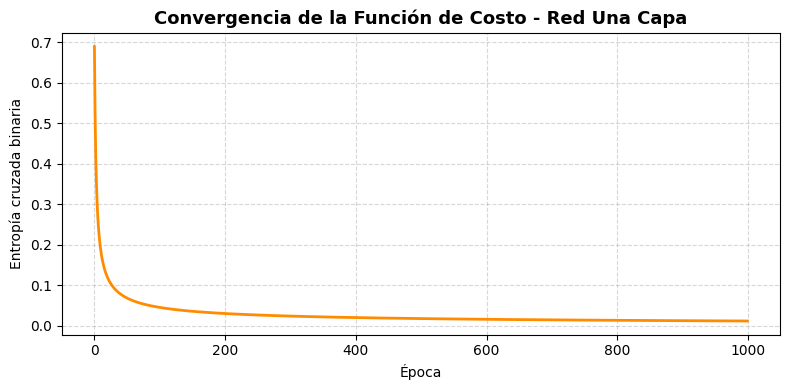


--- Muestra de Predicciones (primeras 10) ---
  Real    Prob(1)   Pred   OK
     0     0.0008      0    ✅
     0     0.0919      0    ✅
     0     0.0001      0    ✅
     0     0.1699      0    ✅
     0     0.0003      0    ✅
     0     0.0000      0    ✅
     0     0.0000      0    ✅
     0     0.0000      0    ✅
     0     0.0000      0    ✅
     0     0.0000      0    ✅


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Dataset: Clasificación lineal 2D (puntos en dos grupos separables)
# ─────────────────────────────────────────────────────────────────────────────
np.random.seed(42)

# Grupo 0: centrado en (1, 1)
clase0 = np.random.randn(50, 2) + np.array([1, 1])
# Grupo 1: centrado en (4, 4)
clase1 = np.random.randn(50, 2) + np.array([4, 4])

X_lineal = np.vstack([clase0, clase1])
y_lineal = np.array([0]*50 + [1]*50)

# Normalización: media 0, desviación estándar 1 (mejora el entrenamiento)
X_norm = (X_lineal - X_lineal.mean(axis=0)) / X_lineal.std(axis=0)

print("=" * 50)
print("  RED NEURONAL DE UNA CAPA")
print("=" * 50)

red_una_capa = RedUnaCapа(tasa_aprendizaje=0.5, epocas=1000)
red_una_capa.entrenar(X_norm, y_lineal, verbose=True)

print(f"\nExactitud final: {red_una_capa.exactitud(X_norm, y_lineal):.1f}%")

# ── Gráfica de convergencia del costo ─────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(red_una_capa.historial_costo, color='darkorange', linewidth=2)
plt.title("Convergencia de la Función de Costo - Red Una Capa",
          fontsize=13, fontweight='bold')
plt.xlabel("Época")
plt.ylabel("Entropía cruzada binaria")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ── Mostrar predicciones detalladas (primeras 10) ────────────────────────────
preds, probs = red_una_capa.predecir(X_norm)
print("\n--- Muestra de Predicciones (primeras 10) ---")
print(f"{'Real':>6} {'Prob(1)':>10} {'Pred':>6} {'OK':>4}")
for i in range(10):
    estado = "✅" if preds[i] == y_lineal[i] else "❌"
    print(f"{y_lineal[i]:>6} {probs[i]:>10.4f} {preds[i]:>6} {estado:>4}")

---
## PARTE 3: Red Neuronal Multicapa (MLP)

Una **red multicapa (MLP - Multi-Layer Perceptron)** agrega capas **ocultas** entre la entrada y la salida.
Esto le permite aprender patrones **no lineales** como el XOR.

### Arquitectura implementada:
```
Entrada (n) → Capa Oculta 1 (ReLU) → Capa Oculta 2 (ReLU) → Salida (Sigmoide)
```

### Funciones de activación usadas:
- **ReLU** (capas ocultas): `f(z) = max(0, z)` — evita el problema del gradiente evanescente
- **Sigmoide** (capa salida): `σ(z) = 1/(1+e^(-z))` — produce probabilidad entre 0 y 1

### Entrenamiento:
- **Forward propagation**: calcular salidas capa por capa
- **Backpropagation**: propagar el error hacia atrás para ajustar todos los pesos

In [8]:
class RedMulticapa:
    """
    Red neuronal multicapa (MLP) implementada desde cero.

    Arquitectura flexible:
        Entrada → [Capa Oculta 1 (ReLU)] → [Capa Oculta 2 (ReLU)] → Salida (Sigmoide)

    Parámetros:
        n_entrada (int)      : Número de características de entrada.
        n_oculta1 (int)      : Neuronas en la primera capa oculta.
        n_oculta2 (int)      : Neuronas en la segunda capa oculta.
        tasa_aprendizaje (float): Paso del descenso de gradiente.
        epocas (int)         : Iteraciones de entrenamiento.
    """

    def __init__(self, n_entrada, n_oculta1=4, n_oculta2=4,
                 tasa_aprendizaje=0.01, epocas=5000):
        self.lr = tasa_aprendizaje
        self.epocas = epocas
        self.historial_costo = []

        # ── Inicialización de parámetros (He init para ReLU) ──────────────────
        # He init: escala por sqrt(2/n_entrada) — óptimo para ReLU
        escala1 = np.sqrt(2.0 / n_entrada)
        escala2 = np.sqrt(2.0 / n_oculta1)
        escala3 = np.sqrt(2.0 / n_oculta2)

        self.params = {
            # Capa 1: Entrada → Oculta 1
            'W1': np.random.randn(n_entrada,  n_oculta1) * escala1,
            'b1': np.zeros((1, n_oculta1)),
            # Capa 2: Oculta 1 → Oculta 2
            'W2': np.random.randn(n_oculta1, n_oculta2) * escala2,
            'b2': np.zeros((1, n_oculta2)),
            # Capa 3: Oculta 2 → Salida
            'W3': np.random.randn(n_oculta2, 1) * escala3,
            'b3': np.zeros((1, 1)),
        }

    # ── Funciones de activación ───────────────────────────────────────────────
    @staticmethod
    def _relu(z):
        """ReLU: max(0, z). Rápida y evita gradiente evanescente en capas ocultas."""
        return np.maximum(0, z)

    @staticmethod
    def _relu_derivada(z):
        """Derivada de ReLU: 1 si z > 0, sino 0."""
        return (z > 0).astype(float)

    @staticmethod
    def _sigmoide(z):
        """Sigmoide estable numéricamente."""
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    # ── Forward Propagation ───────────────────────────────────────────────────
    def _forward(self, X):
        """
        Propagación hacia adelante: calcula la salida pasando X por todas las capas.

        Retorna:
            cache (dict): Valores intermedios necesarios para backpropagation.
            A3 (np.ndarray): Salida final (probabilidades).
        """
        p = self.params

        # Capa 1: z1 = X·W1 + b1,  A1 = ReLU(z1)
        Z1 = np.dot(X,  p['W1']) + p['b1']
        A1 = self._relu(Z1)

        # Capa 2: z2 = A1·W2 + b2,  A2 = ReLU(z2)
        Z2 = np.dot(A1, p['W2']) + p['b2']
        A2 = self._relu(Z2)

        # Capa 3 (salida): z3 = A2·W3 + b3,  A3 = Sigmoide(z3)
        Z3 = np.dot(A2, p['W3']) + p['b3']
        A3 = self._sigmoide(Z3)

        # Guardamos todo para backprop
        cache = {'X': X, 'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2, 'Z3': Z3, 'A3': A3}
        return cache, A3

    # ── Función de costo ──────────────────────────────────────────────────────
    @staticmethod
    def _costo(y_real, y_pred):
        """Entropía cruzada binaria."""
        m = y_real.shape[0]
        eps = 1e-15
        return -np.mean(
            y_real * np.log(y_pred + eps) +
            (1 - y_real) * np.log(1 - y_pred + eps)
        )

    # ── Backpropagation ───────────────────────────────────────────────────────
    def _backward(self, cache, y):
        """
        Retropropagación del error: calcula gradientes de W y b en cada capa
        usando la regla de la cadena (Chain Rule).

        Flujo del gradiente (hacia atrás):
            Capa 3 → Capa 2 → Capa 1
        """
        m = y.shape[0]
        p = self.params

        # ── Gradiente capa 3 (sigmoide + entropía cruzada) ──
        dA3 = cache['A3'] - y                              # Error de salida
        dW3 = np.dot(cache['A2'].T, dA3) / m
        db3 = np.mean(dA3, axis=0, keepdims=True)

        # ── Gradiente capa 2 (ReLU) ──
        dA2 = np.dot(dA3, p['W3'].T) * self._relu_derivada(cache['Z2'])
        dW2 = np.dot(cache['A1'].T, dA2) / m
        db2 = np.mean(dA2, axis=0, keepdims=True)

        # ── Gradiente capa 1 (ReLU) ──
        dA1 = np.dot(dA2, p['W2'].T) * self._relu_derivada(cache['Z1'])
        dW1 = np.dot(cache['X'].T, dA1) / m
        db1 = np.mean(dA1, axis=0, keepdims=True)

        return {'dW1': dW1, 'db1': db1,
                'dW2': dW2, 'db2': db2,
                'dW3': dW3, 'db3': db3}

    # ── Actualización de parámetros ───────────────────────────────────────────
    def _actualizar(self, gradientes):
        """Descenso de gradiente: W ← W - α·dW,  b ← b - α·db"""
        for capa in ['1', '2', '3']:
            self.params[f'W{capa}'] -= self.lr * gradientes[f'dW{capa}']
            self.params[f'b{capa}'] -= self.lr * gradientes[f'db{capa}']

    # ── Entrenamiento completo ────────────────────────────────────────────────
    def entrenar(self, X, y, verbose=True):
        """Ciclo completo: forward → costo → backward → actualizar."""
        y = y.reshape(-1, 1)  # Asegurar forma columna

        for epoca in range(self.epocas):
            cache, A3 = self._forward(X)
            costo = self._costo(y, A3)
            self.historial_costo.append(costo)
            gradientes = self._backward(cache, y)
            self._actualizar(gradientes)

            if verbose and (epoca + 1) % 1000 == 0:
                print(f"  Época {epoca+1:5d} → Costo: {costo:.6f}")

    # ── Predicción y exactitud ────────────────────────────────────────────────
    def predecir(self, X, umbral=0.5):
        _, A3 = self._forward(X)
        return (A3 >= umbral).astype(int).flatten(), A3.flatten()

    def exactitud(self, X, y):
        preds, _ = self.predecir(X)
        return np.mean(preds == y) * 100


print("✅ Clase RedMulticapa definida.")

✅ Clase RedMulticapa definida.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Prueba MLP: Compuerta XOR (NO linealmente separable - el perceptrón falla aquí)
# ─────────────────────────────────────────────────────────────────────────────
# XOR: salida 1 solo cuando las entradas son diferentes
X_xor = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])

print("=" * 50)
print("  RED MULTICAPA - Compuerta XOR")
print("  (No separable linealmente — perceptrón falla)")
print("=" * 50)

# Verificar que el perceptrón FALLA en XOR
p_xor = Perceptron(tasa_aprendizaje=0.1, epocas=20)
p_xor.entrenar(X_xor, y_xor)
print(f"\n❌ Perceptrón en XOR → Exactitud: {p_xor.exactitud(X_xor, y_xor):.1f}% (esperado < 100%)")

# Ahora con la red multicapa
print("\n" + "=" * 50)
mlp_xor = RedMulticapa(n_entrada=2, n_oculta1=4, n_oculta2=4,
                        tasa_aprendizaje=0.1, epocas=5000)
mlp_xor.entrenar(X_xor, y_xor, verbose=True)

exactitud_mlp = mlp_xor.exactitud(X_xor, y_xor)
print(f"\n✅ MLP en XOR → Exactitud: {exactitud_mlp:.1f}%")

# Mostrar predicciones detalladas
preds, probs = mlp_xor.predecir(X_xor)
print("\n--- Predicciones del MLP en XOR ---")
print(f"{'Entrada':>10} {'Prob(1)':>10} {'Pred':>6} {'Real':>6} {'OK':>4}")
for i, x in enumerate(X_xor):
    estado = "✅" if preds[i] == y_xor[i] else "❌"
    print(f"  {str(x.astype(int)):>8} {probs[i]:>10.4f} {preds[i]:>6} {y_xor[i]:>6} {estado}")

  RED MULTICAPA - Compuerta XOR
  (No separable linealmente — perceptrón falla)
  Época  1 → Errores: 3
  Época  2 → Errores: 3
  Época  3 → Errores: 4
  Época  4 → Errores: 4
  Época  5 → Errores: 4
  Época  6 → Errores: 4
  Época  7 → Errores: 4
  Época  8 → Errores: 4
  Época  9 → Errores: 4
  Época 10 → Errores: 4
  Época 11 → Errores: 4
  Época 12 → Errores: 4
  Época 13 → Errores: 4
  Época 14 → Errores: 4
  Época 15 → Errores: 4
  Época 16 → Errores: 4
  Época 17 → Errores: 4
  Época 18 → Errores: 4
  Época 19 → Errores: 4
  Época 20 → Errores: 4

❌ Perceptrón en XOR → Exactitud: 50.0% (esperado < 100%)

  Época  1000 → Costo: 0.031926
  Época  2000 → Costo: 0.009862
  Época  3000 → Costo: 0.005645
  Época  4000 → Costo: 0.003919
  Época  5000 → Costo: 0.002990

✅ MLP en XOR → Exactitud: 100.0%

--- Predicciones del MLP en XOR ---
   Entrada    Prob(1)   Pred   Real   OK
     [0 0]     0.0012      0      0 ✅
     [0 1]     0.9998      1      1 ✅
     [1 0]     0.9896      1     

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Prueba MLP: Dataset más grande con patrón no lineal (espiral / círculos)
# ─────────────────────────────────────────────────────────────────────────────
np.random.seed(0)
n = 200

# Clase 0: puntos dentro de un círculo de radio ~1
angulos0 = np.random.uniform(0, 2*np.pi, n)
r0 = np.random.uniform(0, 1, n)
X0 = np.column_stack([r0*np.cos(angulos0), r0*np.sin(angulos0)])

# Clase 1: puntos en un anillo de radio entre 1.5 y 2.5
angulos1 = np.random.uniform(0, 2*np.pi, n)
r1 = np.random.uniform(1.5, 2.5, n)
X1 = np.column_stack([r1*np.cos(angulos1), r1*np.sin(angulos1)])

X_circ = np.vstack([X0, X1])
y_circ = np.array([0]*n + [1]*n)

# Normalizar
X_circ_norm = (X_circ - X_circ.mean(axis=0)) / X_circ.std(axis=0)

print("=" * 50)
print("  RED MULTICAPA - Clasificación Circular")
print("  (No separable linealmente)")
print("=" * 50)

mlp_circ = RedMulticapa(n_entrada=2, n_oculta1=8, n_oculta2=8,
                         tasa_aprendizaje=0.05, epocas=5000)
mlp_circ.entrenar(X_circ_norm, y_circ, verbose=True)

print(f"\n✅ Exactitud en dataset circular: {mlp_circ.exactitud(X_circ_norm, y_circ):.1f}%")

  RED MULTICAPA - Clasificación Circular
  (No separable linealmente)
  Época  1000 → Costo: 0.013716
  Época  2000 → Costo: 0.005214
  Época  3000 → Costo: 0.002987
  Época  4000 → Costo: 0.002027
  Época  5000 → Costo: 0.001507

✅ Exactitud en dataset circular: 100.0%


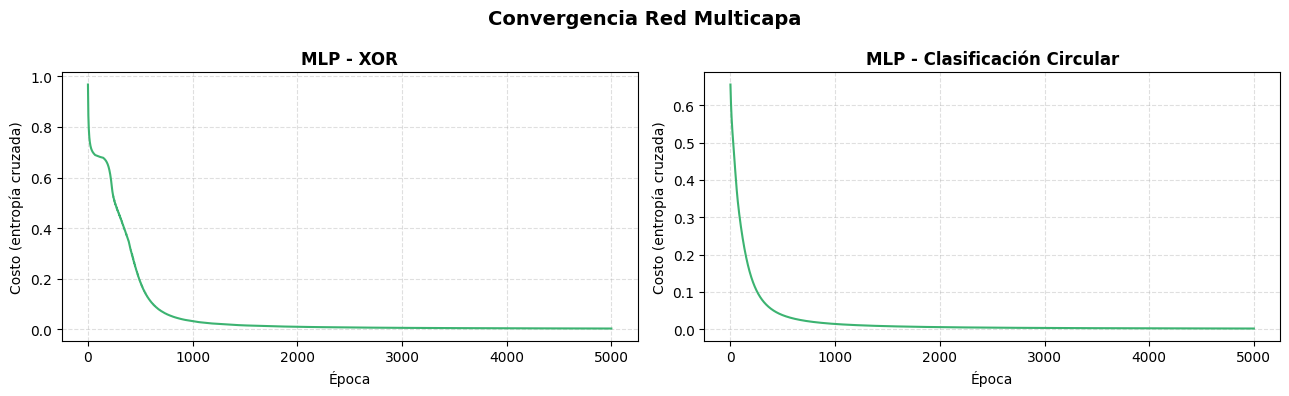

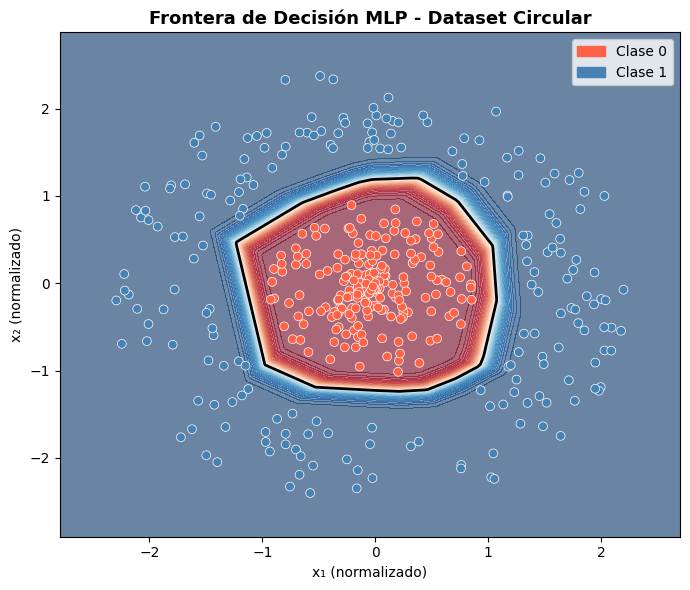

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualizaciones: Convergencia + Frontera de decisión MLP
# ─────────────────────────────────────────────────────────────────────────────

def graficar_frontera_mlp(modelo, X, y, titulo, resolucion=200):
    """
    Dibuja la región de decisión de la red neuronal usando una malla de puntos.
    Colorea cada punto de la malla según la clase predicha.
    """
    # Crear malla de puntos
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolucion),
        np.linspace(y_min, y_max, resolucion)
    )
    malla = np.c_[xx.ravel(), yy.ravel()]

    # Predecir clase para cada punto de la malla
    _, probs_malla = modelo.predecir(malla)
    Z = probs_malla.reshape(xx.shape)

    # Graficar
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

    colores = ['tomato' if etq == 0 else 'steelblue' for etq in y]
    ax.scatter(X[:, 0], X[:, 1], c=colores, s=40, edgecolors='white', linewidths=0.5, zorder=3)

    parche0 = mpatches.Patch(color='tomato', label='Clase 0')
    parche1 = mpatches.Patch(color='steelblue', label='Clase 1')
    ax.legend(handles=[parche0, parche1])
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_xlabel("x₁ (normalizado)")
    ax.set_ylabel("x₂ (normalizado)")
    plt.tight_layout()
    plt.show()


# Gráfica de convergencia comparativa
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, modelo, titulo in zip(
    axes,
    [mlp_xor, mlp_circ],
    ["MLP - XOR", "MLP - Clasificación Circular"]
):
    ax.plot(modelo.historial_costo, color='mediumseagreen', linewidth=1.5)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel("Época")
    ax.set_ylabel("Costo (entropía cruzada)")
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Convergencia Red Multicapa", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Frontera de decisión del MLP circular
graficar_frontera_mlp(mlp_circ, X_circ_norm, y_circ,
                      "Frontera de Decisión MLP - Dataset Circular")

---
## 📋 Conclusiones Técnicas

### 1. Perceptrón Simple
- **Funcionamiento:** El perceptrón calcula un puntaje `z = w·x + b` y aplica una función de umbral para clasificar.
- **Convergencia:** La regla de actualización de Rosenblatt garantiza convergencia **solo si el problema es linealmente separable** (AND, OR).
- **Limitación:** Fracasa en XOR porque no existe ninguna línea recta que pueda separar las clases.

### 2. Red de Una Capa
- Usar la función sigmoide y entropía cruzada permite un aprendizaje más suave y estable que la regla del perceptrón.
- Los gradientes permiten ajustes continuos, no solo cuando hay error.
- Sigue siendo lineal en su frontera de decisión.

### 3. Red Multicapa (MLP)
- Las capas ocultas con ReLU permiten aprender **representaciones no lineales** del problema.
- El backpropagation propaga el error hacia atrás usando la **regla de la cadena**, ajustando todos los pesos de la red.
- Pudo resolver XOR (frontera curva) y la clasificación circular, ambos imposibles para modelos lineales.
- La inicialización He (escala `√(2/n)`) fue clave para una convergencia estable con ReLU.

### 4. Observaciones generales
| Modelo | XOR | Circular | Frontera |
|--------|-----|----------|----------|
| Perceptrón | ❌ | ❌ | Línea recta |
| Red 1 capa | ❌ | ❌ | Línea recta |
| MLP (2 capas ocultas) | ✅ | ✅ | Curva / compleja |

> **Conclusión principal:** La profundidad y las funciones de activación no lineales son los ingredientes clave que convierten una red neuronal en un aproximador universal de funciones.